In [1]:
# ============================================================
# CELL 1: Mount Drive + Config (same as notebook 01)
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import os, torch

class Config:
    PROJECT_ROOT    = '/content/drive/MyDrive/FinDocVQA'
    DATA_DIR        = os.path.join(PROJECT_ROOT, 'data')
    DOCVQA_DIR      = os.path.join(DATA_DIR, 'docvqa')
    CHARTQA_DIR     = os.path.join(DATA_DIR, 'chartqa')
    MODELS_DIR      = os.path.join(PROJECT_ROOT, 'models')
    OUTPUTS_DIR     = os.path.join(PROJECT_ROOT, 'outputs')
    SEED = 42

cfg = Config()
print(f"✓ GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")
print(f"✓ Project root: {cfg.PROJECT_ROOT}")

Mounted at /content/drive
✓ GPU: Tesla T4
✓ Project root: /content/drive/MyDrive/FinDocVQA


In [2]:
# ============================================================
# CELL 2: Load Datasets from Drive
# ============================================================

from datasets import load_from_disk

print("Loading datasets from Drive...")
docvqa = load_from_disk(os.path.join(cfg.DOCVQA_DIR, 'docvqa_dataset'))
chartqa = load_from_disk(os.path.join(cfg.CHARTQA_DIR, 'chartqa_dataset'))

print(f"✓ DocVQA: {len(docvqa['train'])} train, {len(docvqa['validation'])} val")
print(f"✓ ChartQA: {len(chartqa['train'])} train, {len(chartqa['val'])} val")

Loading datasets from Drive...


Loading dataset from disk:   0%|          | 0/59 [00:00<?, ?it/s]

✓ DocVQA: 39463 train, 5349 val
✓ ChartQA: 28299 train, 1920 val


In [4]:
# ============================================================
# CELL 2b: Install dependencies for this notebook
# ============================================================

%%capture
!pip install pytesseract
!apt-get -qq install tesseract-ocr
!pip install transformers accelerate

In [5]:
# ============================================================
# CELL 3: Baseline — Tesseract OCR + RoBERTa QA Pipeline
# ============================================================

import pytesseract
from PIL import Image
from transformers import pipeline
from io import BytesIO
import time

# Load the QA pipeline (RoBERTa fine-tuned on SQuAD2)
print("Loading RoBERTa QA model...")
qa_pipeline = pipeline(
    "question-answering",
    model="deepset/roberta-base-squad2",
    device=0 if torch.cuda.is_available() else -1
)
print("✓ Model loaded")

def ocr_roberta_predict(image, question):
    """
    Baseline: OCR → RoBERTa QA
    """
    if isinstance(image, dict) and 'bytes' in image:
        image = Image.open(BytesIO(image['bytes']))

    # Convert to RGB (Tesseract can fail on RGBA/grayscale)
    image = image.convert('RGB')

    ocr_text = pytesseract.image_to_string(image)

    if not ocr_text.strip():
        return {"answer": "", "score": 0.0, "ocr_text": ""}

    # Truncate but keep it simple — this is a known baseline weakness
    context = ocr_text[:4000]

    try:
        result = qa_pipeline(question=question, context=context)
        return {
            "answer": result['answer'],
            "score": result['score'],
            "ocr_text": ocr_text
        }
    except Exception as e:
        print(f"  QA error: {e}")
        return {"answer": "", "score": 0.0, "ocr_text": ocr_text}

# Quick test on one example
example = docvqa['validation'][0]
print(f"\nTest example:")
print(f"  Question: {example['question']}")
print(f"  Ground truth: {example['answers']}")

result = ocr_roberta_predict(example['image'], example['question'])
print(f"  Predicted: {result['answer']}")
print(f"  Confidence: {result['score']:.4f}")
print(f"  OCR text length: {len(result['ocr_text'])} chars")

Loading RoBERTa QA model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/496M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/79.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

✓ Model loaded

Test example:
  Question: what is the page no or page mentioned ?
  Ground truth: ['2', 'page 2']
  Predicted: topics or rubrics
  Confidence: 0.0007
  OCR text length: 872 chars


In [6]:
# ============================================================
# CELL 4: Evaluate Baseline on DocVQA Validation (subset)
# ============================================================
# Running on full 5349 val examples would take ~2 hours with OCR.
# We evaluate on 500 examples first to get a reliable estimate.
# ============================================================

import numpy as np
from tqdm import tqdm
import time
import json

def normalized_levenshtein(s1, s2):
    """Compute normalized Levenshtein similarity between two strings."""
    s1, s2 = s1.lower().strip(), s2.lower().strip()
    if s1 == s2:
        return 1.0
    if len(s1) == 0 or len(s2) == 0:
        return 0.0

    # Levenshtein distance
    m, n = len(s1), len(s2)
    dp = [[0] * (n + 1) for _ in range(m + 1)]
    for i in range(m + 1):
        dp[i][0] = i
    for j in range(n + 1):
        dp[0][j] = j
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if s1[i-1] == s2[j-1]:
                dp[i][j] = dp[i-1][j-1]
            else:
                dp[i][j] = 1 + min(dp[i-1][j], dp[i][j-1], dp[i-1][j-1])

    dist = dp[m][n]
    max_len = max(m, n)
    similarity = 1.0 - (dist / max_len)
    return similarity

def compute_anls(prediction, ground_truths, threshold=0.5):
    """
    ANLS metric: max normalized Levenshtein similarity across
    all ground truth answers. If best score < threshold, return 0.
    """
    if not prediction:
        return 0.0
    best = max(normalized_levenshtein(prediction, gt) for gt in ground_truths)
    return best if best >= threshold else 0.0

def compute_exact_match(prediction, ground_truths):
    """Exact match: 1 if prediction matches any ground truth exactly."""
    pred = prediction.lower().strip()
    return float(any(pred == gt.lower().strip() for gt in ground_truths))


# --- Run evaluation ---
NUM_EVAL = 500
val_data = docvqa['validation']

# Deterministic subset
np.random.seed(42)
eval_indices = np.random.choice(len(val_data), NUM_EVAL, replace=False)

results = []
anls_scores = []
em_scores = []

print(f"Evaluating OCR+RoBERTa baseline on {NUM_EVAL} DocVQA validation examples...")
print("=" * 60)

start_time = time.time()

for i, idx in enumerate(tqdm(eval_indices, desc="Evaluating")):
    example = val_data[int(idx)]
    question = example['question']
    ground_truths = example['answers']

    pred = ocr_roberta_predict(example['image'], question)

    anls = compute_anls(pred['answer'], ground_truths)
    em = compute_exact_match(pred['answer'], ground_truths)

    anls_scores.append(anls)
    em_scores.append(em)

    results.append({
        'index': int(idx),
        'question': question,
        'ground_truths': ground_truths,
        'prediction': pred['answer'],
        'confidence': pred['score'],
        'anls': anls,
        'exact_match': em,
    })

elapsed = time.time() - start_time

# --- Print results ---
print("\n" + "=" * 60)
print(f"OCR + RoBERTa BASELINE RESULTS ({NUM_EVAL} examples)")
print("=" * 60)
print(f"  ANLS:         {np.mean(anls_scores):.4f}")
print(f"  Exact Match:  {np.mean(em_scores):.4f}")
print(f"  Time:         {elapsed:.0f}s ({elapsed/NUM_EVAL:.1f}s per example)")
print("=" * 60)

# --- Save results ---
results_path = os.path.join(cfg.OUTPUTS_DIR, 'baseline_ocr_roberta_results.json')
with open(results_path, 'w') as f:
    json.dump({
        'model': 'Tesseract OCR + RoBERTa (deepset/roberta-base-squad2)',
        'dataset': 'DocVQA validation',
        'num_examples': NUM_EVAL,
        'anls': float(np.mean(anls_scores)),
        'exact_match': float(np.mean(em_scores)),
        'per_example': results
    }, f, indent=2)
print(f"\n✓ Results saved to {results_path}")

Evaluating OCR+RoBERTa baseline on 500 DocVQA validation examples...


Evaluating: 100%|██████████| 500/500 [17:52<00:00,  2.14s/it]


OCR + RoBERTa BASELINE RESULTS (500 examples)
  ANLS:         0.3260
  Exact Match:  0.2200
  Time:         1072s (2.1s per example)

✓ Results saved to /content/drive/MyDrive/FinDocVQA/outputs/baseline_ocr_roberta_results.json


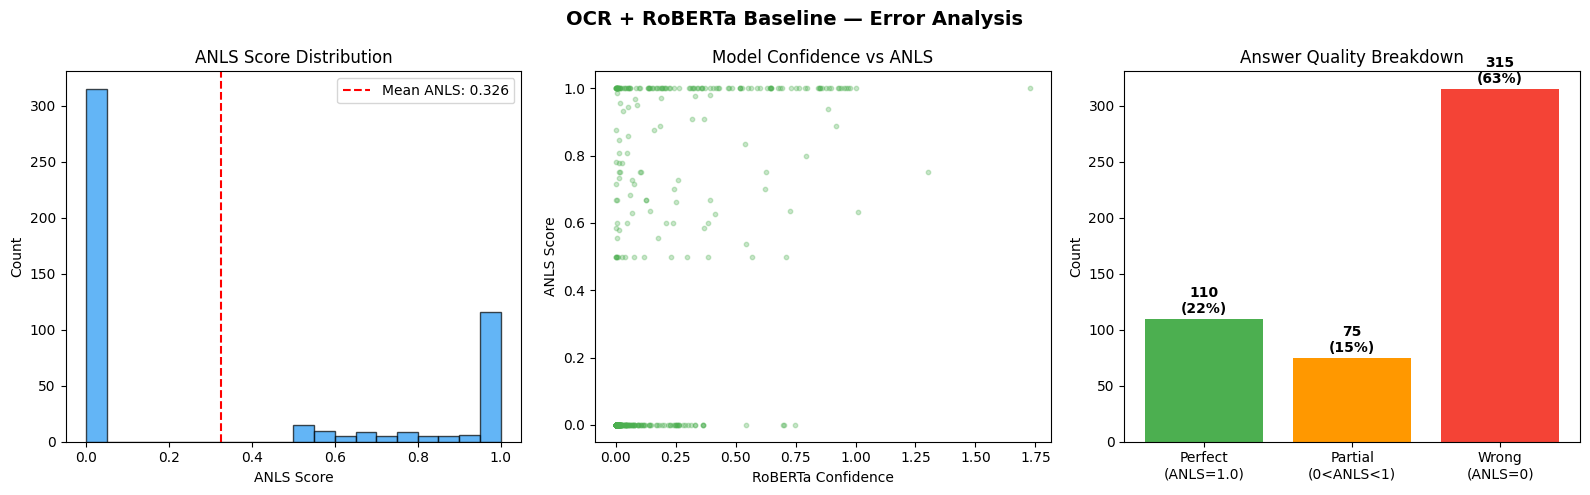


5 WORST FAILURES (ANLS=0, highest confidence):
------------------------------------------------------------
  Q: What is the ‘maximum amount of loan due from western express industries limited at any time during the previous year’?
  GT: Rs.8,35,98,040
  Pred: Rs.10,96,52,390 (conf: 0.7483)

  Q: What effect do artificial sweeteners have on blood sugar level?
  GT: no effect
  Pred: no (conf: 0.7001)

  Q: To which staff category does Nan Allison belong?
  GT: PROGRAM STAFF
  Pred: Nutrition Health Director (conf: 0.6995)

  Q: who is the director of department of Allied medical professions and services ?
  GT: ralph c. kuhli, M.P.H.
  Pred: Cs-shu helaigs Miah (conf: 0.5421)

  Q: What is the “unit of quantity” of Paperboards and paper?
  GT: Tonne
  Pred: 3,52,500 (conf: 0.3655)



In [7]:
# ============================================================
# CELL 5: Baseline Error Analysis
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Load results
anls_arr = np.array([r['anls'] for r in results])
em_arr = np.array([r['exact_match'] for r in results])
conf_arr = np.array([r['confidence'] for r in results])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('OCR + RoBERTa Baseline — Error Analysis', fontsize=14, fontweight='bold')

# --- 1. ANLS score distribution ---
ax = axes[0]
ax.hist(anls_arr, bins=20, color='#2196F3', edgecolor='black', alpha=0.7)
ax.axvline(np.mean(anls_arr), color='red', linestyle='--',
           label=f'Mean ANLS: {np.mean(anls_arr):.3f}')
ax.set_title('ANLS Score Distribution')
ax.set_xlabel('ANLS Score')
ax.set_ylabel('Count')
ax.legend()

# --- 2. Confidence vs ANLS ---
ax = axes[1]
ax.scatter(conf_arr, anls_arr, alpha=0.3, s=10, color='#4CAF50')
ax.set_title('Model Confidence vs ANLS')
ax.set_xlabel('RoBERTa Confidence')
ax.set_ylabel('ANLS Score')

# --- 3. Correct vs Incorrect breakdown ---
ax = axes[2]
perfect = np.sum(anls_arr == 1.0)
partial = np.sum((anls_arr > 0) & (anls_arr < 1.0))
wrong = np.sum(anls_arr == 0)
bars = ax.bar(['Perfect\n(ANLS=1.0)', 'Partial\n(0<ANLS<1)', 'Wrong\n(ANLS=0)'],
              [perfect, partial, wrong],
              color=['#4CAF50', '#FF9800', '#F44336'])
for bar, v in zip(bars, [perfect, partial, wrong]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{v}\n({v/len(anls_arr)*100:.0f}%)', ha='center', fontweight='bold')
ax.set_title('Answer Quality Breakdown')
ax.set_ylabel('Count')

plt.tight_layout()
plt.savefig(os.path.join(cfg.OUTPUTS_DIR, 'baseline_error_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

# --- Show worst failures ---
print("\n5 WORST FAILURES (ANLS=0, highest confidence):")
print("-" * 60)
failures = [r for r in results if r['anls'] == 0]
failures.sort(key=lambda x: x['confidence'], reverse=True)
for r in failures[:5]:
    print(f"  Q: {r['question']}")
    print(f"  GT: {r['ground_truths'][0]}")
    print(f"  Pred: {r['prediction']} (conf: {r['confidence']:.4f})")
    print()